# How many chains should Tier-1 runs use?

Five runs, identical except for the chain count: **C12**, free parameters `a1`+`c3`, the
Tier-1 data design (C16 Equivalents time series + per-species endpoints at 720 s for the
baseline and six 0.1x conditions -> 7 ODE solves per gradient), `tune=300`, early stopping
off, and an equal **sampling-only** budget of 2 A100-equivalent hours each. Warmup sits
outside that budget so its cost is measured rather than charged against sampling. All runs
are pinned to A100s so per-draw times are comparable; the protocol is
`Notes/tier1_experiment_plan.md` section 1.

Two things trade off:

- **Throughput.** Chains are `jax.vmap`-ed and advance in lockstep, so extra chains are
  nearly free until the GPU saturates -- and every chain pays its own warmup.
- **Diagnostic power.** r-hat and the rank-ECDF check are between-chain statistics; with
  few chains they are themselves noisy.

**Decision rule, fixed before the runs (do not revise it after seeing the numbers):** take
the smallest chain count whose bulk ESS per A100-hour is within 10% of the best, with a
floor of 8 chains for diagnostic power. If ESS per hour is still flat at 64 chains, take
the largest count whose seconds per draw stays within 20% of the 4-chain run.

In [1]:
import subprocess, json as _json, pathlib
import numpy as np, pandas as pd, matplotlib.pyplot as plt

REMOTE_PY = "/projects/anth4580/software/anaconda/envs/Bayesian/bin/python"

# Analysis scripts run on an Alpine interactive (acompile) node, never the login node:
# these walk every checkpoint and recompute r-hat/ESS, which is real work and does not
# belong on a shared login node. SLURM_CONF has to be set explicitly -- loading the slurm
# module alone leaves it pointing at whichever cluster the login node belongs to.
SRUN = ("export SLURM_CONF=/curc/slurm/alpine/etc/slurm.conf; "
        "srun --partition=acompile --qos=compile --account=ucb634_asc2 "
        "--nodes=1 --ntasks=1 --cpus-per-task=4 --time=00:40:00 ")

EXPORT = "/projects/anth4580/Bayesian/job_files/tier1/export_chaintest.py"

def pull():
    p = subprocess.run(["ssh", "curc", SRUN + f"{REMOTE_PY} {EXPORT}"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    if p.returncode != 0:
        raise RuntimeError(p.stderr.decode()[-2000:])
    pathlib.Path("chaintest.json").write_bytes(p.stdout)
    return _json.loads(p.stdout)

D = pull()
RUNS = {v["chains"]: v for v in D.values() if "error" not in v}
print(f"{'run':<34}{'chains':>7}{'warmup':>12}{'sampling draws':>16}{'phase':>10}  gpu")
for name, v in D.items():
    if "error" in v:
        print(f"{name:<34}   {v['error']}")
        continue
    print(f"{name:<34}{v['chains']:>7}{str(v['warmup_done']) + '/' + str(v['tune']):>12}"
          f"{v['sampling_done']:>16}{v['phase']:>10}  {v.get('gpu')}")
if not RUNS:
    print("\nNo run has checkpointed yet -- every section below will say so rather than fail.")

run                                chains      warmup  sampling draws     phase  gpu
Chain C12 - a1c3_4chains                4     300/300             415  sampling  NVIDIA A100-PCIE-40GB
Chain C12 - a1c3_8chains                8     300/300             525  sampling  NVIDIA A100-PCIE-40GB
Chain C12 - a1c3_16chains              16     300/300             410  sampling  NVIDIA A100-PCIE-40GB
Chain C12 - a1c3_32chains              32     205/300               0    warmup  NVIDIA A100-PCIE-40GB
Chain C12 - a1c3_64chains              64     125/300               0    warmup  NVIDIA A100-PCIE-40GB


## 1. Throughput: what does a chain cost?

If chains were free, seconds per draw would be flat in chain count and total draws per hour
would rise linearly. The point where seconds per draw starts climbing is where the GPU
saturates, and beyond it extra chains buy proportionally less.

,chains,warmup_s_per_step,warmup_total_h,s_per_draw,draws,draws_x_chains,sampling_h,s_per_draw_vs_smallest,draws_per_a100_hour
0,4,22.20,2.05,17.50,415,1660,2.02,1.00,205.7
1,8,31.68,3.30,26.29,525,4200,3.97,1.50,136.9
2,16,54.67,6.87,42.82,410,6560,5.06,2.45,84.1
3,32,103.86,9.53,NaN,0,0,NaN,NaN,NaN
4,64,129.86,8.92,NaN,0,0,NaN,NaN,NaN


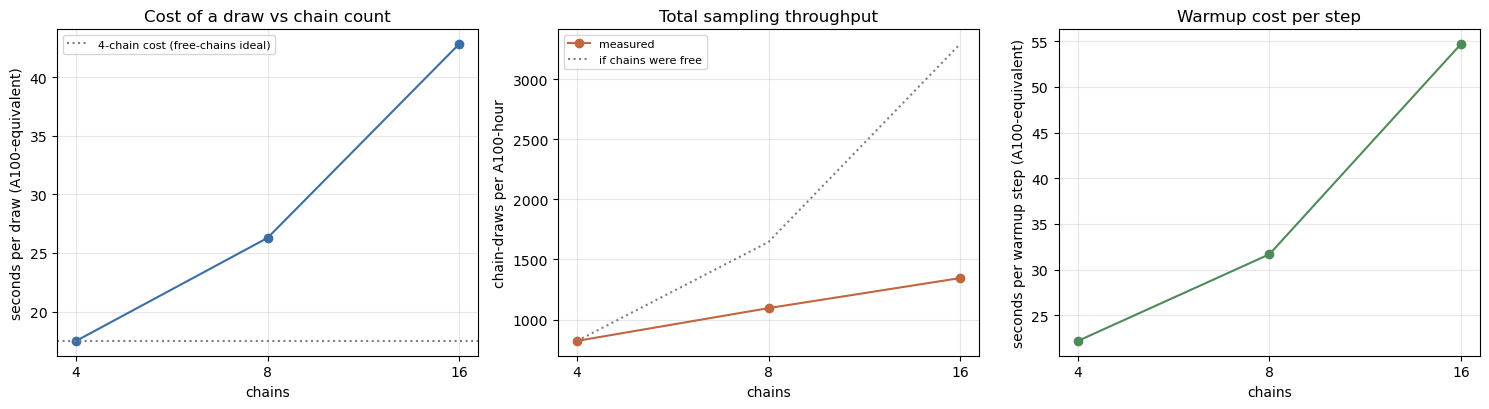

In [2]:
rows = []
for n in sorted(RUNS):
    v = RUNS[n]
    w, s = v.get("warmup_s_per_step_a100"), v.get("sampling_s_per_step_a100")
    rows.append(dict(chains=n,
                     warmup_s_per_step=round(w, 2) if w else None,
                     warmup_total_h=round((v.get("warmup_span_s_a100") or 0) / 3600, 2) or None,
                     s_per_draw=round(s, 2) if s else None,
                     draws=v["sampling_done"],
                     draws_x_chains=v["sampling_done"] * n,
                     sampling_h=round((v.get("sampling_span_s_a100") or 0) / 3600, 2) or None))
COLS_T = ["chains", "warmup_s_per_step", "warmup_total_h", "s_per_draw", "draws",
          "draws_x_chains", "sampling_h"]
df_t = pd.DataFrame(rows, columns=COLS_T)   # explicit columns: an empty frame still has them
if not df_t.empty and df_t["s_per_draw"].notna().any():
    b = df_t.dropna(subset=["s_per_draw"]).iloc[0]
    df_t["s_per_draw_vs_smallest"] = (df_t["s_per_draw"] / b["s_per_draw"]).round(2)
    df_t["draws_per_a100_hour"] = (3600 / df_t["s_per_draw"]).round(1)
display(df_t)

if df_t["s_per_draw"].notna().sum() >= 2:
    d = df_t.dropna(subset=["s_per_draw"])
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    axes[0].plot(d["chains"], d["s_per_draw"], "o-", color="#3b6ea5")
    axes[0].axhline(d["s_per_draw"].iloc[0], ls=":", color="gray",
                    label=f"{int(d['chains'].iloc[0])}-chain cost (free-chains ideal)")
    axes[0].set_ylabel("seconds per draw (A100-equivalent)"); axes[0].legend(fontsize=8)
    axes[0].set_title("Cost of a draw vs chain count")
    axes[1].plot(d["chains"], d["chains"] * 3600 / d["s_per_draw"], "o-", color="#c1663f", label="measured")
    ideal = d["chains"] * 3600 / d["s_per_draw"].iloc[0]
    axes[1].plot(d["chains"], ideal, ":", color="gray", label="if chains were free")
    axes[1].set_ylabel("chain-draws per A100-hour"); axes[1].legend(fontsize=8)
    axes[1].set_title("Total sampling throughput")
    if d["warmup_s_per_step"].notna().any():
        axes[2].plot(d["chains"], d["warmup_s_per_step"], "o-", color="#4f8a5b")
        axes[2].set_ylabel("seconds per warmup step (A100-equivalent)")
    axes[2].set_title("Warmup cost per step")
    for ax in axes:
        ax.set_xscale("log", base=2); ax.set_xticks(d["chains"]); ax.set_xticklabels(d["chains"].astype(int))
        ax.set_xlabel("chains"); ax.grid(alpha=0.3)
    fig.tight_layout(); plt.show()
else:
    print("Need sampling-phase timings from at least two runs.")

## 2. Efficiency: ESS per unit compute

Throughput is not the goal; effective samples are. Bulk ESS is summed across chains, so
more chains can raise total ESS even when each chain is slower. The figure of merit is bulk
ESS per A100-hour of sampling, and the binding parameter is whichever of `a1`, `c3` is
worse.

,chains,sampling_h,worst_param,ess_bulk_min,ess_tail_min,rhat_max,ess_bulk_per_a100_h,ess_per_h_per_chain,pct_of_best
0,4,2.02,a1_log__,1251.5,1096.7,1.0027,620.0,155.00,71.6
1,8,3.97,c3_log__,2640.6,2303.0,1.0043,664.6,83.08,76.8
2,16,5.06,a1_log__,4380.1,4007.1,1.0013,865.9,54.12,100.0


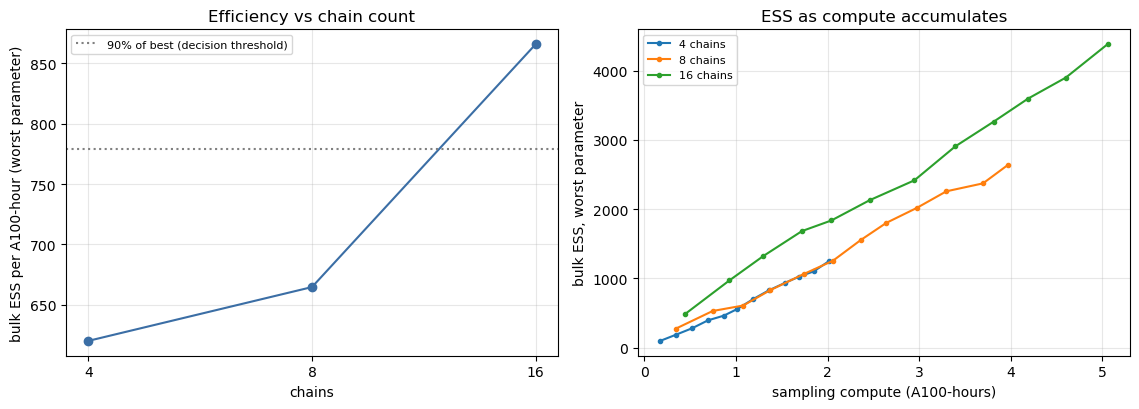

In [3]:
rows = []
for n in sorted(RUNS):
    v = RUNS[n]
    post = v.get("posterior", {})
    if not post:
        continue
    h = (v.get("sampling_span_s_a100") or 0) / 3600
    worst = min(post, key=lambda p: post[p]["ess_bulk"])
    row = dict(chains=n, sampling_h=round(h, 2) if h else None,
               worst_param=worst,
               ess_bulk_min=round(min(p["ess_bulk"] for p in post.values()), 1),
               ess_tail_min=round(min(p["ess_tail"] for p in post.values()), 1),
               rhat_max=round(max(p["rhat"] for p in post.values()), 4))
    if h:
        row["ess_bulk_per_a100_h"] = round(row["ess_bulk_min"] / h, 1)
        row["ess_per_h_per_chain"] = round(row["ess_bulk_min"] / h / n, 2)
    rows.append(row)
COLS_E = ["chains", "sampling_h", "worst_param", "ess_bulk_min", "ess_tail_min", "rhat_max",
          "ess_bulk_per_a100_h", "ess_per_h_per_chain"]
df_e = pd.DataFrame(rows, columns=COLS_E)
if not df_e.empty and df_e["ess_bulk_per_a100_h"].notna().any():
    best = df_e["ess_bulk_per_a100_h"].max()
    df_e["pct_of_best"] = (100 * df_e["ess_bulk_per_a100_h"] / best).round(1)
display(df_e)

if df_e["ess_bulk_per_a100_h"].notna().sum() >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
    axes[0].plot(df_e["chains"], df_e["ess_bulk_per_a100_h"], "o-", color="#3b6ea5")
    axes[0].axhline(0.9 * best, ls=":", color="gray", label="90% of best (decision threshold)")
    axes[0].set_ylabel("bulk ESS per A100-hour (worst parameter)"); axes[0].legend(fontsize=8)
    axes[0].set_title("Efficiency vs chain count")
    for n in sorted(RUNS):
        traj = RUNS[n].get("trajectory", {})
        if not traj:
            continue
        p = min(traj, key=lambda k: traj[k][-1]["ess_bulk"] if traj[k] else np.inf)
        pts = [(t["sampling_s_a100"] / 3600, t["ess_bulk"]) for t in traj[p] if t.get("sampling_s_a100")]
        if pts:
            axes[1].plot([x for x, _ in pts], [y for _, y in pts], "o-", ms=3, label=f"{n} chains")
    axes[1].set_xlabel("sampling compute (A100-hours)"); axes[1].set_ylabel("bulk ESS, worst parameter")
    axes[1].set_title("ESS as compute accumulates"); axes[1].legend(fontsize=8)
    axes[0].set_xscale("log", base=2); axes[0].set_xticks(df_e["chains"]); axes[0].set_xticklabels(df_e["chains"].astype(int))
    axes[0].set_xlabel("chains")
    for ax in axes: ax.grid(alpha=0.3)
    fig.tight_layout(); plt.show()
else:
    print("Need posterior draws from at least two runs.")

## 3. Diagnostic power: how noisy is r-hat at each chain count?

Taken from the runs themselves rather than a separate experiment: split a run's chains into
disjoint groups of 4, 8, 16 and 32 and compute r-hat and bulk ESS within each group. All
groups sample the same posterior, so the **spread across groups** at one size is the
uncertainty of that diagnostic at that many chains. A chain count whose r-hat estimates
scatter widely cannot be trusted to decide convergence, however fast it samples.

,run_chains,param,group_size,n_groups,rhat_min,rhat_max,rhat_spread,ess_cv
0,8,a1_log__,4,2,1.0040,1.0075,0.0035,0.235
1,8,c3_log__,4,2,1.0018,1.0024,0.0006,0.133
2,16,a1_log__,4,4,1.0006,1.0034,0.0028,0.092
3,16,a1_log__,8,2,1.0006,1.0025,0.0019,0.049
4,16,c3_log__,4,4,1.0008,1.0023,0.0015,0.010
5,16,c3_log__,8,2,1.0009,1.0012,0.0003,0.003


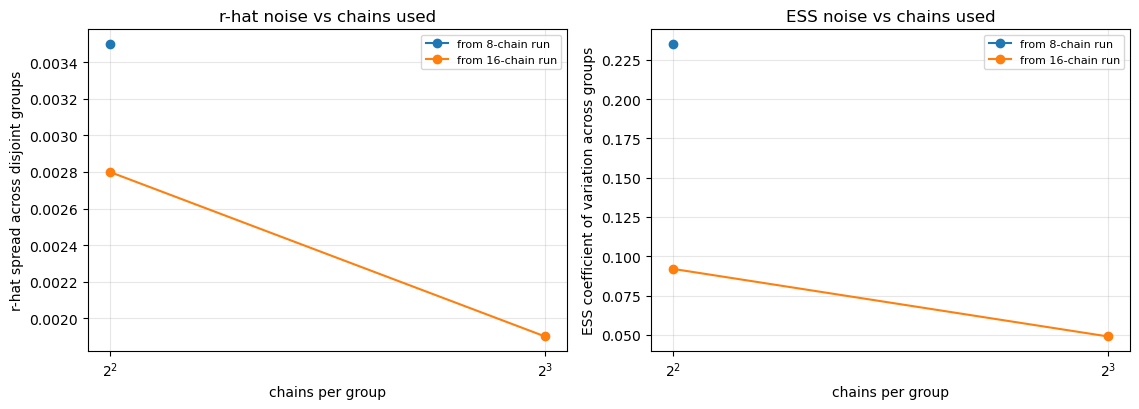

In [4]:
rows = []
for n in sorted(RUNS):
    for p, per_size in (RUNS[n].get("groups") or {}).items():
        for g, vals in per_size.items():
            r = np.array(vals["rhat"], float); e = np.array(vals["ess_bulk"], float)
            rows.append(dict(run_chains=n, param=p, group_size=int(g), n_groups=len(r),
                             rhat_min=round(r.min(), 4), rhat_max=round(r.max(), 4),
                             rhat_spread=round(r.max() - r.min(), 4),
                             ess_cv=round(float(e.std() / e.mean()), 3) if e.mean() else None))
df_g = pd.DataFrame(rows, columns=["run_chains", "param", "group_size", "n_groups",
                                   "rhat_min", "rhat_max", "rhat_spread", "ess_cv"])
display(df_g)

if not df_g.empty:
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
    for n, d in df_g.groupby("run_chains"):
        agg = d.groupby("group_size").agg(spread=("rhat_spread", "max"), cv=("ess_cv", "max")).reset_index()
        axes[0].plot(agg["group_size"], agg["spread"], "o-", label=f"from {n}-chain run")
        axes[1].plot(agg["group_size"], agg["cv"], "o-", label=f"from {n}-chain run")
    axes[0].set_ylabel("r-hat spread across disjoint groups"); axes[0].set_title("r-hat noise vs chains used")
    axes[1].set_ylabel("ESS coefficient of variation across groups"); axes[1].set_title("ESS noise vs chains used")
    for ax in axes:
        ax.set_xscale("log", base=2); ax.set_xlabel("chains per group"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
    fig.tight_layout(); plt.show()
else:
    print("Needs a run with at least 8 chains and 50+ sampling draws.")

## 4. Sanity: did the chain count change the geometry?

It should not. Adapted step size, acceptance and leapfrog steps per draw are properties of
the posterior; if they move systematically with chain count, the runs are not comparable and
the efficiency numbers above mean less than they appear to.

In [5]:
rows = []
for n in sorted(RUNS):
    st = RUNS[n].get("sampler_stats", {})
    if not st:
        continue
    rows.append(dict(chains=n,
                     step_size=round(st.get("step_size", {}).get("median", float("nan")), 4),
                     accept=round(st.get("acceptance_rate", {}).get("mean", float("nan")), 3),
                     leapfrog_median=st.get("n_steps", {}).get("median"),
                     leapfrog_max=st.get("n_steps", {}).get("max"),
                     divergence_rate=round(st.get("diverging", {}).get("mean", float("nan")), 4),
                     tree_depth_max=st.get("tree_depth", {}).get("max")))
display(pd.DataFrame(rows, columns=["chains", "step_size", "accept", "leapfrog_median",
                                    "leapfrog_max", "divergence_rate", "tree_depth_max"]))

,chains,step_size,accept,leapfrog_median,leapfrog_max,divergence_rate,tree_depth_max
0,4,0.8494,0.918,3.0,15.0,0.0,4.0
1,8,0.8861,0.925,3.0,31.0,0.0,5.0
2,16,0.8674,0.921,3.0,31.0,0.0,5.0


## 5. The decision

Applies the rule stated at the top, unchanged.

In [6]:
if df_e["ess_bulk_per_a100_h"].notna().sum() >= 2 and df_t["s_per_draw"].notna().sum() >= 1:
    d = df_e.dropna(subset=["ess_bulk_per_a100_h"]).sort_values("chains")
    best = d["ess_bulk_per_a100_h"].max()
    within10 = d[(d["ess_bulk_per_a100_h"] >= 0.9 * best) & (d["chains"] >= 8)]
    t = df_t.dropna(subset=["s_per_draw"]).sort_values("chains")
    flat = (t["s_per_draw"].iloc[-1] <= 1.2 * t["s_per_draw"].iloc[0]) if len(t) >= 2 else False
    print(f"best efficiency: {best:.1f} bulk ESS per A100-hour at "
          f"{int(d.loc[d['ess_bulk_per_a100_h'].idxmax(), 'chains'])} chains")
    if flat:
        pick = int(t["chains"].iloc[-1])
        print(f"seconds per draw at the largest count is within 20% of the smallest "
              f"({t['s_per_draw'].iloc[-1]:.2f} vs {t['s_per_draw'].iloc[0]:.2f} s) -- "
              f"chains are still nearly free, so the rule takes the largest: {pick} chains")
    elif not within10.empty:
        pick = int(within10["chains"].iloc[0])
        print(f"smallest chain count within 10% of best efficiency and >= 8: {pick} chains")
    else:
        pick = int(d.loc[d["ess_bulk_per_a100_h"].idxmax(), "chains"])
        print(f"nothing within 10% of best at >= 8 chains; taking the most efficient: {pick} chains")
    if not df_g.empty:
        sp = df_g[df_g["group_size"] == pick]["rhat_spread"]
        if not sp.empty:
            print(f"r-hat spread across disjoint {pick}-chain groups: {sp.max():.4f} "
                  f"(smaller is a more trustworthy convergence test)")
else:
    print("Decision pending: not enough runs have posterior draws yet.")

best efficiency: 865.9 bulk ESS per A100-hour at 16 chains
smallest chain count within 10% of best efficiency and >= 8: 16 chains
